# HOMEWORK 2
For this homework you will have to complete and implement the colour balancing for:
* Gray world algorithm
* Scale-by-max algorithm

You are free to use your own images. Experiment with more images and think about the effect each of the algorithms has on the resulting (balanced) image.

### Colour Balancing
In this notebook we will show different type of colour balancing making use of von Kries' hypothesis.

***********************
Gray world
Shape (rows, cols, channels):  (350, 625, 3)
Mean R:  93.170304
Mean G:  115.07389714285715
Mean B:  111.218144
Brightest channel:  115.07389714285715
kr:  1.2350920003744663
kg:  1.0
kb:  1.0346683823716494
***********************

***********************
Scale by max
Shape (rows, cols, channels):  (756, 1008, 3)
Max R:  255
Max G:  255
Max B:  237
kr:  1.0
kg:  1.0
kb:  1.0759493670886076
***********************



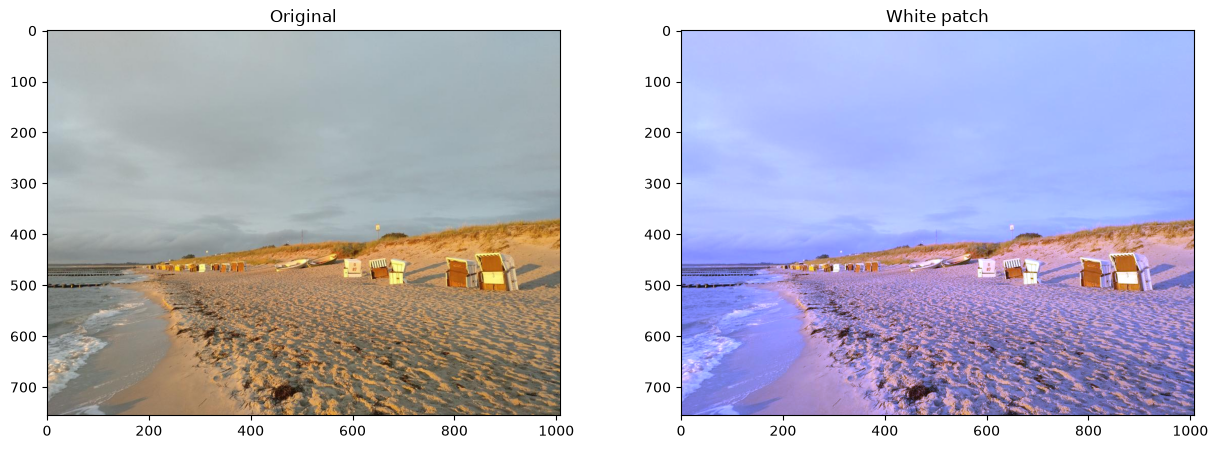

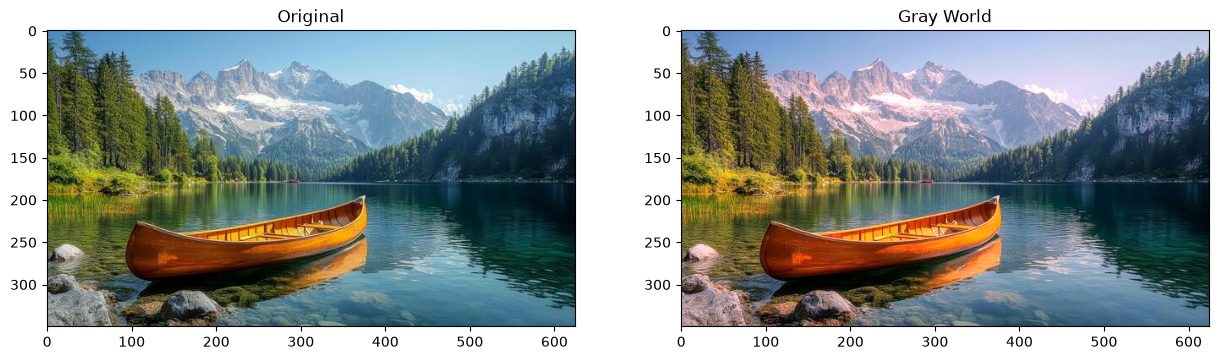

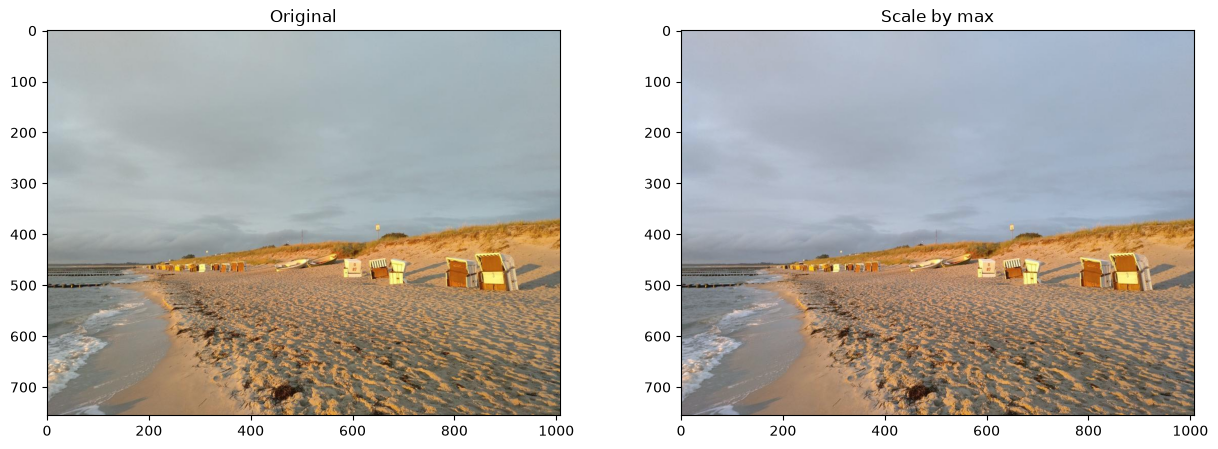

In [45]:
import cv2
import sys
import numpy as np
from matplotlib import pyplot as plt

def display_image(img, title="", show_axis = True):
    if isinstance(img, list):
        plt.figure()
        for idx, image in enumerate(img):
            plt.subplot(1,len(img),idx+1)
            plt.imshow(image)
            plt.title(title[idx])
    else:
        plt.figure()
        plt.imshow(img)
        plt.title(title)
    
    if show_axis == False:
        plt.axis('off')

def main(args):
    plt.rcParams['figure.figsize'] = [15, 5]
    img = cv2.imread('../data/sea.jpg')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    white_patch(img)

    img = cv2.imread('../data/example.jpg')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray_world(img)

    img = cv2.imread('../data/sea.jpg')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    scale_by_max(img)

def white_patch(img):
    # Define white patch and the coefficients
    row, col = 485, 864 
    white = img[row, col, :]
    coeffs = 255.0/white

    # Apply white balancing and generate balanced image
    balanced = np.zeros_like(img, dtype=np.float32)
    for channel in range(3):
        balanced[..., channel] = img[..., channel] * coeffs[channel]

    # White patching does not guarantee that the dynamic range is preserved, images must be clipped.
    balanced = balanced/255
    balanced[balanced > 1] = 1

    display_image([img, balanced], ["Original", "White patch"])

def gray_world(img):
    # Compute the mean values for all three colour channels (red, green, blue)
    mean_r = np.mean(img[:, :, 0])
    mean_g = np.mean(img[:, :, 1])
    mean_b = np.mean(img[:, :, 2])
    brightest_channel = max(mean_r, mean_g, mean_b)
    
    # Compute the coefficients kr, kg, kb
    # Note: there are 3 coefficients to compute but we only have 2 equations.
    # Therefore, you have to make an assumption, fix the value of one of the
    # coefficients and compute the remining two
    # Hint: You can fix the coefficient of the brightest colour channel to 1.
    kr = brightest_channel / mean_r 
    kg = brightest_channel / mean_g 
    kb = brightest_channel / mean_b

    # as float to prevent overflow
    balanced = img.astype(np.float32)
    # apply coefficients
    balanced[:, :, 0] *= kr;
    balanced[:, :, 1] *= kg;
    balanced[:, :, 2] *= kb;

    # clip it to uint8 back
    balanced = np.clip(balanced, 0, 255).astype(np.uint8)

    display_image([img, balanced], ["Original", "Gray World"])
    
    print('***********************')
    print('Gray world')
    print(f'Shape (rows, cols, channels): ', img.shape)
    print(f'Mean R: ', mean_r)
    print(f'Mean G: ', mean_g)
    print(f'Mean B: ', mean_b)
    print(f'Brightest channel: ', brightest_channel)
    print(f'kr: ', kr)
    print(f'kg: ', kg)
    print(f'kb: ', kb)
    print('***********************\n')

def scale_by_max(img):
    # Compute the maximum values for all three colour channels (red, green, blue)
    max_r = np.max(img[:, :, 0])
    max_g = np.max(img[:, :, 1])
    max_b = np.max(img[:, :, 2])

    kr = 255.0 / max_r
    kg = 255.0 / max_g
    kb = 255.0 / max_b
    
    print('***********************')
    print('Scale by max') 
    print(f'Shape (rows, cols, channels): ', img.shape)
    print(f'Max R: ', max_r)
    print(f'Max G: ', max_g)
    print(f'Max B: ', max_b)
    print(f'kr: ', kr)
    print(f'kg: ', kg)
    print(f'kb: ', kb)
    print('***********************\n')
    
    # Apply scale-by-max balancing and generate the balanced image
    # as float to prevent overflow
    balanced = img.astype(np.float32)
    # apply coefficients
    balanced[:, :, 0] *= kr;
    balanced[:, :, 1] *= kg;
    balanced[:, :, 2] *= kb;

    # clip it to uint8 back
    balanced = np.clip(balanced, 0, 255).astype(np.uint8)
    
    display_image([img, balanced], ["Original", "Scale by max"])


if __name__ == '__main__':
    main(sys.argv)